# Exploratory Data Analysis (EDA)
## Dataset: bureau & bureau_balance

**Author:** Oknardo Tulung  
**LinkedIn:** https://www.linkedin.com/in/oknardo-tulung/  
**GitHub:** https://github.com/oknardo/Home_Credit_Scorecard_Model

---

## 📌 Project Overview
This notebook performs a comprehensive Exploratory Data Analysis (EDA) on the `bureau` and `bureau_balance` datasets from the Home Credit risk modeling case. These tables contain clients' previous credit history reported to the Credit Bureau, which serve as key external behavioral signals for predicting loan default.

---

## 🎯 Objectives
- Understand the structure and relationship between `bureau` and `bureau_balance`
- Identify data quality issues (missing values, outliers, inconsistencies)
- Analyze the distribution of key variables
- Explore relationships between aggregated features and the target variable (loan default)
- Generate aggregated features ready for merging into the main table

---

## 🔍 Analysis Scope
The analysis includes:
- Missing Value Analysis
- Univariate analysis (distribution of individual variables)
- Bivariate analysis (relationships between features)
- Aggregation strategy (bureau_balance to SK_ID_BUREAU, bureau to SK_ID_CURR)
- Bivariate analysis of aggregated features vs TARGET
- Initial business-driven interpretation of credit bureau behavior

---

## 🧠 Key Questions
- What is the credit history profile of applicants in the Credit Bureau?
- How do the number and status of previous credits relate to default behavior?
- What aggregated signals from bureau balance are most predictive of default?
- Are there patterns in overdue payments or credit types that differentiate defaulters?

---

## 🛠 Tools & Libraries
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

---

## 📊 Output
The output of this EDA will serve as:
- Aggregated bureau features ready for merging into the main modeling table
- Business insights on external credit behavior
- Input for feature selection and credit scoring models

# Importing Library

In [1]:
# Installation Library
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
# Hide Warning
import warnings
warnings.filterwarnings('ignore')

# Importing Library
import pandas as pd
# Setting Pandas Row Display Max
pd.set_option('display.max_rows', None)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math


# Importing Dataset

In [3]:
# Dataset bureau
bureau_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\bureau.csv'
df_bureau = pd.read_csv(bureau_path)

# Dataset bureau_balance
bureau_balance_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\bureau_balance.csv'
df_bureau_balance = pd.read_csv(bureau_balance_path)

# Dataset application_train (for bivariate aggregated features vs TARGET)
application_train_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\application_train.csv'
df_app_train = pd.read_csv(application_train_path)

# 1. About Dataset

## 1.1 Bureau
The dataset consists of **1,716,428 observations** and **17 features**, representing clients' previous credit records reported to the Credit Bureau. Each row corresponds to a single previous credit entry linked to an applicant in the main dataset via `SK_ID_CURR`.

The features can be grouped into several categories:
- **Key identifiers**: `SK_ID_CURR` (link to main table) and `SK_ID_BUREAU` (link to bureau_balance)
- **Numerical features**: credit amounts, overdue amounts, and temporal variables (in days)
- **Categorical features**: credit status, currency, and credit type

In [4]:
df_bureau.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           str    
 3   CREDIT_CURRENCY         str    
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             str    
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), str(3)
memory usage: 222.6 MB


## 1.2 Bureau Balance
The dataset consists of **27,299,925 observations** and **3 features**, representing monthly balance snapshots of each previous credit recorded in the Credit Bureau. Each row corresponds to one month of history for a given credit entry, linked via `SK_ID_BUREAU`.

The features can be grouped into several categories:
- **Key identifier**: `SK_ID_BUREAU` (link to bureau table)
- **Numerical feature**: `MONTHS_BALANCE`, representing the relative month of the snapshot
- **Categorical feature**: `STATUS`, indicating the repayment status for that month

In [5]:
df_bureau_balance.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 27299925 entries, 0 to 27299924
Data columns (total 3 columns):
 #   Column          Dtype
---  ------          -----
 0   SK_ID_BUREAU    int64
 1   MONTHS_BALANCE  int64
 2   STATUS          str  
dtypes: int64(2), str(1)
memory usage: 624.8 MB


## 1.3 Relation to Main Table

The `bureau` table contains **305,811 unique applicants**, covering **85.69%** of the 307,511 applicants in `application_train`. This means approximately 14.31% of applicants have no recorded credit history in the Credit Bureau.

The `bureau` table links to `bureau_balance` via `SK_ID_BUREAU`. Out of **1,716,428** unique bureau credits, only **817,395 (47.62%)** have monthly balance history in `bureau_balance`, indicating that not all bureau credits have observable monthly snapshots.

On average, each applicant has **5.61 bureau credits**, and each bureau credit has approximately **33.40 months** of balance history.

In [8]:
# Unique SK_ID_CURR in bureau vs application_train
print("Unique SK_ID_CURR in bureau      :", df_bureau['SK_ID_CURR'].nunique())
print("Unique SK_ID_CURR in app_train   :", df_app_train['SK_ID_CURR'].nunique())

# Coverage: percentage of applicants in app_train that exist in bureau
covered = df_app_train['SK_ID_CURR'].isin(df_bureau['SK_ID_CURR']).sum()
print(f"Applicants in app_train covered by bureau: {covered / df_app_train.shape[0] * 100:.2f}%")

# Unique SK_ID_BUREAU in bureau vs bureau_balance
print("\nUnique SK_ID_BUREAU in bureau        :", df_bureau['SK_ID_BUREAU'].nunique())
print("Unique SK_ID_BUREAU in bureau_balance:", df_bureau_balance['SK_ID_BUREAU'].nunique())

# Average number of bureau credits per applicant
avg_credits = df_bureau.groupby('SK_ID_CURR')['SK_ID_BUREAU'].count().mean()
print(f"\nAvg bureau credits per applicant: {avg_credits:.2f}")

# Average months of balance history per SK_ID_BUREAU in bureau_balance
avg_months = df_bureau_balance.groupby('SK_ID_BUREAU')['MONTHS_BALANCE'].count().mean()
print(f"Avg months of history per bureau credit: {avg_months:.2f}")

Unique SK_ID_CURR in bureau      : 305811
Unique SK_ID_CURR in app_train   : 307511
Applicants in app_train covered by bureau: 85.69%

Unique SK_ID_BUREAU in bureau        : 1716428
Unique SK_ID_BUREAU in bureau_balance: 817395

Avg bureau credits per applicant: 5.61
Avg months of history per bureau credit: 33.40


# 2. Credit Active Distribution

The credit active distribution shows the overall status of previous credits recorded in the Credit Bureau. Understanding the proportion of active, closed, and bad debt credits provides an initial signal of the credit behavior profile across applicants.

- Total Closed: 1,079,273 (~62.88%)
- Total Active: 630,607 (~36.74%)
- Total Sold: 6,527 (~0.38%)
- Total Bad debt: 21 (~0.00%)

The majority of bureau credits are **Closed (~62.88%)**, indicating that most previous credits have been fully settled. Active credits account for **36.74%**, representing ongoing obligations at the time of application. `Bad debt` and `Sold` together represent less than **0.40%** of all records, but may carry disproportionate risk signal and warrant attention during feature engineering.

In [31]:
# Credit active value counts
print(df_bureau['CREDIT_ACTIVE'].value_counts())
print(f"\nCredit Active Distribution (%):")
print((df_bureau['CREDIT_ACTIVE'].value_counts() / len(df_bureau) * 100).round(2))

CREDIT_ACTIVE
Closed      1079273
Active       630607
Sold           6527
Bad debt         21
Name: count, dtype: int64

Credit Active Distribution (%):
CREDIT_ACTIVE
Closed      62.88
Active      36.74
Sold         0.38
Bad debt     0.00
Name: count, dtype: float64


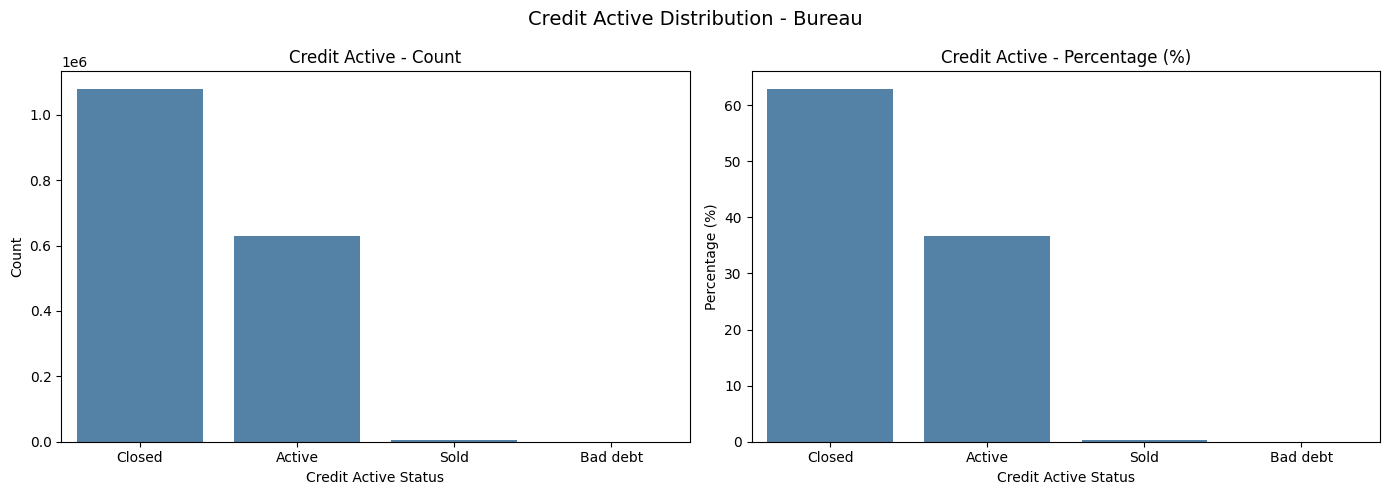

In [32]:
# Bar plot - credit active distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
credit_active_counts = df_bureau['CREDIT_ACTIVE'].value_counts()
sns.barplot(x=credit_active_counts.index, y=credit_active_counts.values, ax=axes[0], color='steelblue')
axes[0].set_title('Credit Active - Count')
axes[0].set_xlabel('Credit Active Status')
axes[0].set_ylabel('Count')

# Percentage plot
credit_active_pct = df_bureau['CREDIT_ACTIVE'].value_counts(normalize=True) * 100
sns.barplot(x=credit_active_pct.index, y=credit_active_pct.values, ax=axes[1], color='steelblue')
axes[1].set_title('Credit Active - Percentage (%)')
axes[1].set_xlabel('Credit Active Status')
axes[1].set_ylabel('Percentage (%)')

plt.suptitle('Credit Active Distribution - Bureau', fontsize=14)
plt.tight_layout()
plt.show()

# 3. Missing Value Analysis

The missing value analysis is conducted to assess data quality and identify potential information contained within missing data.

The approach includes:
- **Measuring** the count and percentage of missing values for each feature
- **Evaluating** the likely cause of missingness based on domain context
- **Defining** a handling strategy for each missing feature

The results of this analysis serve as recommendations for the data handling stage, including imputing values and deciding whether missingness itself carries meaningful signal.

## 3.1 Bureau


In [41]:
df_bureau.isnull().sum()

SK_ID_CURR                      0
SK_ID_BUREAU                    0
CREDIT_ACTIVE                   0
CREDIT_CURRENCY                 0
DAYS_CREDIT                     0
CREDIT_DAY_OVERDUE              0
DAYS_CREDIT_ENDDATE        105553
DAYS_ENDDATE_FACT          633653
AMT_CREDIT_MAX_OVERDUE    1124488
CNT_CREDIT_PROLONG              0
AMT_CREDIT_SUM                 13
AMT_CREDIT_SUM_DEBT        257669
AMT_CREDIT_SUM_LIMIT       591780
AMT_CREDIT_SUM_OVERDUE          0
CREDIT_TYPE                     0
DAYS_CREDIT_UPDATE              0
AMT_ANNUITY               1226791
dtype: int64

In [49]:
# Check missing values: count, percentage, and data type per feature
missing_bureau = (
    df_bureau.isnull()
    # sum = total missing values, mean = proportion missing
    .agg(['sum', 'mean'])
    .T
    # Rename columns
    .rename(columns={
        'sum': 'Missing_Count',
        'mean': 'Missing_Percentage'
    })
    .assign(
        # Convert proportion to percentage
        Missing_Percentage=lambda x: (x['Missing_Percentage'] * 100).round(2),
        # Add data type for each feature
        Data_Type=df_app_train.dtypes
    )
    # Keep only features with missing values
    .query('Missing_Count > 0')
    .sort_values('Missing_Percentage', ascending=False)
    .reset_index(names='Feature')
)

print(missing_bureau)

                  Feature  Missing_Count  Missing_Percentage Data_Type
0             AMT_ANNUITY      1226791.0               71.47   float64
1  AMT_CREDIT_MAX_OVERDUE      1124488.0               65.51       NaN
2       DAYS_ENDDATE_FACT       633653.0               36.92       NaN
3    AMT_CREDIT_SUM_LIMIT       591780.0               34.48       NaN
4     AMT_CREDIT_SUM_DEBT       257669.0               15.01       NaN
5     DAYS_CREDIT_ENDDATE       105553.0                6.15       NaN
6          AMT_CREDIT_SUM           13.0                0.00       NaN


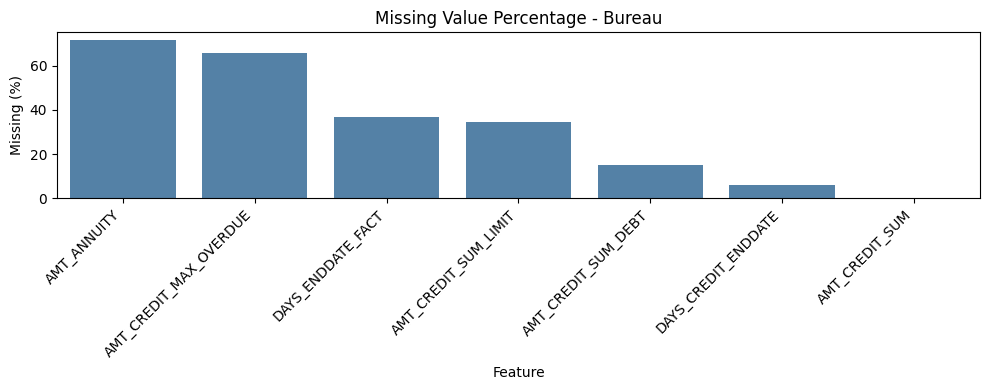

In [48]:
# Visualization of missing values
plt.figure(figsize=(10, 4))
sns.barplot(x=missing_bureau['Feature'], y=missing_bureau['Missing_Percentage'], color='steelblue')
plt.title('Missing Value Percentage - Bureau')
plt.ylabel('Missing (%)')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3.2 Bureau Balance

In [51]:
# Check missing values: count, percentage, and data type per feature
missing_bureau_balance = (
    df_bureau_balance.isnull()
    # sum = total missing values, mean = proportion missing
    .agg(['sum', 'mean'])
    .T
    # Rename columns
    .rename(columns={
        'sum': 'Missing_Count',
        'mean': 'Missing_Percentage'
    })
    .assign(
        # Convert proportion to percentage
        Missing_Percentage=lambda x: (x['Missing_Percentage'] * 100).round(2),
        # Add data type for each feature
        Data_Type=df_app_train.dtypes
    )
    # Keep only features with missing values
    .query('Missing_Count > 0')
    .sort_values('Missing_Percentage', ascending=False)
    .reset_index(names='Feature')
)

print(missing_bureau_balance)

Empty DataFrame
Columns: [Feature, Missing_Count, Missing_Percentage, Data_Type]
Index: []


## Key Findings & Handling Strategies

- The `bureau` dataset contains **7 features with missing values**, all of which are numerical. 
- The `bureau_balance` has no missing values.

Key observations:
- `AMT_ANNUITY` (71.47%) and `AMT_CREDIT_MAX_OVERDUE` (65.51%) have the highest missing rates, likely because not all credit types carry annuity or overdue records
- `DAYS_ENDDATE_FACT` (36.92%) is missing for credits that are still active, as no actual end date exists yet
- `AMT_CREDIT_SUM_LIMIT` (34.48%) is typically only applicable for revolving credits such as credit cards
- `AMT_CREDIT_SUM_DEBT` (15.01%) and `DAYS_CREDIT_ENDDATE` (6.15%) have moderate missing rates
- `AMT_CREDIT_SUM` (0.00%) has negligible missing values

**Handling Strategy:**
- `AMT_ANNUITY`, `AMT_CREDIT_MAX_OVERDUE`, `AMT_CREDIT_SUM_LIMIT`: impute with **0**, as missing likely indicates absence of the condition rather than unknown value
- `DAYS_ENDDATE_FACT`: impute with **0** or leave as-is; missing indicates credit is still active
- `AMT_CREDIT_SUM_DEBT`, `DAYS_CREDIT_ENDDATE`, `AMT_CREDIT_SUM`: impute with **median** per `CREDIT_TYPE` group

# 4. Numerical Features Analysis

Numerical features in the `bureau` and `bureau_balance` datasets are analyzed to understand their distributions, central tendencies, and relationships. This section covers both univariate and bivariate analysis before aggregation.

The approach includes:
- **Describing** each feature through summary statistics
- **Visualizing** distributions to detect skewness and anomalies
- **Detecting** outliers using boxplots
- **Examining** pairwise correlations between numerical features

## 4.1 Bureau


In [57]:
# Select numerical columns
num_cols_bureau = df_bureau.select_dtypes(include='number').columns

### 4.1.1 Univariate Analysis

Univariate analysis examines each numerical feature independently to understand its distribution, central tendency, and spread. This serves as the foundation before exploring relationships between features.

The approach includes:
- **Describing** each feature through summary statistics (mean, median, std, min, max)
- **Identifying** potential anomalies, skewness, and extreme values

#### 4.1.1.1 Statistical Descriptive

In [59]:
df_bureau[num_cols_bureau].describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,1716428.0,2.782149e+05,1.029386e+05,100001.000,188866.75,278055.0,367426.00,4.562550e+05
SK_ID_BUREAU,1716428.0,5.924434e+06,5.322657e+05,5000000.000,5463953.75,5926303.5,6385681.25,6.843457e+06
DAYS_CREDIT,1716428.0,-1.142108e+03,7.951649e+02,-2922.000,-1666.00,-987.0,-474.00,0.000000e+00
CREDIT_DAY_OVERDUE,1716428.0,8.181666e-01,3.654443e+01,0.000,0.00,0.0,0.00,2.792000e+03
DAYS_CREDIT_ENDDATE,1610875.0,5.105174e+02,4.994220e+03,-42060.000,-1138.00,-330.0,474.00,3.119900e+04
DAYS_ENDDATE_FACT,1082775.0,-1.017437e+03,7.140106e+02,-42023.000,-1489.00,-897.0,-425.00,0.000000e+00
AMT_CREDIT_MAX_OVERDUE,591940.0,3.825418e+03,2.060316e+05,0.000,0.00,0.0,0.00,1.159872e+08
CNT_CREDIT_PROLONG,1716428.0,6.410406e-03,9.622391e-02,0.000,0.00,0.0,0.00,9.000000e+00
AMT_CREDIT_SUM,1716415.0,3.549946e+05,1.149811e+06,0.000,51300.00,125518.5,315000.00,5.850000e+08
AMT_CREDIT_SUM_DEBT,1458759.0,1.370851e+05,6.774011e+05,-4705600.320,0.00,0.0,40153.50,1.701000e+08


#### Key Findings

**DAYS_CREDIT — Credit History Depth**
Mean of -1,142 days (~3.1 years before application), ranging from -2,922 to 0. Most applicants have a reasonably long credit history, with 75% of credits opened more than 474 days before application.

**DAYS_CREDIT_ENDDATE — Mix of Active and Closed Credits**
Median of -330 (already ended) but max of 31,199 (far into the future), confirming the mix of closed and active credits. The wide range reflects heterogeneous credit portfolios across applicants.

**DAYS_ENDDATE_FACT — Closed Credits Only**
Only 1,082,775 non-null values (vs 1,716,428 rows), consistent with missing values being active credits. All values are negative or zero, confirming this field only applies to closed credits.

**AMT_CREDIT_MAX_OVERDUE — Extreme Outliers**
Median is 0 but max reaches 115,987,200, indicating most credits have no overdue history but a small number of records have extreme overdue amounts. Requires capping before modeling.

**AMT_CREDIT_SUM — Right-Skewed Credit Amounts**
Mean of 354,995 vs median of 125,519, heavily right-skewed. Max of 585,000,000 confirms extreme outliers. Log transformation or capping recommended.

**AMT_CREDIT_SUM_DEBT — Negative Values Detected**
Min of -4,705,600 is suspicious and likely a data entry error or encoding issue. Requires investigation and handling before aggregation.

**AMT_CREDIT_SUM_LIMIT — Mostly Zero**
Median and 75th percentile are both 0, confirming this feature is only applicable for revolving credit types. Negative min value also warrants investigation.

**CNT_CREDIT_PROLONG and AMT_CREDIT_SUM_OVERDUE — Near-Zero**
Both have median of 0 with rare non-zero values, indicating credit prolongation and overdue amounts are uncommon across the portfolio.

**AMT_ANNUITY — Sparse with Outliers**
Only 489,637 non-null values (28.53% coverage). Median is 0 but max reaches 118,453,400, suggesting extreme outliers among the subset that has annuity records.

---

#### 4.1.1.2 Distribution Plot

Distribution plots are used to examine the shape of each numerical feature - whether it is normally distributed, right-skewed, or contains anomalies. Features with high skewness may require log transformation during preprocessing.

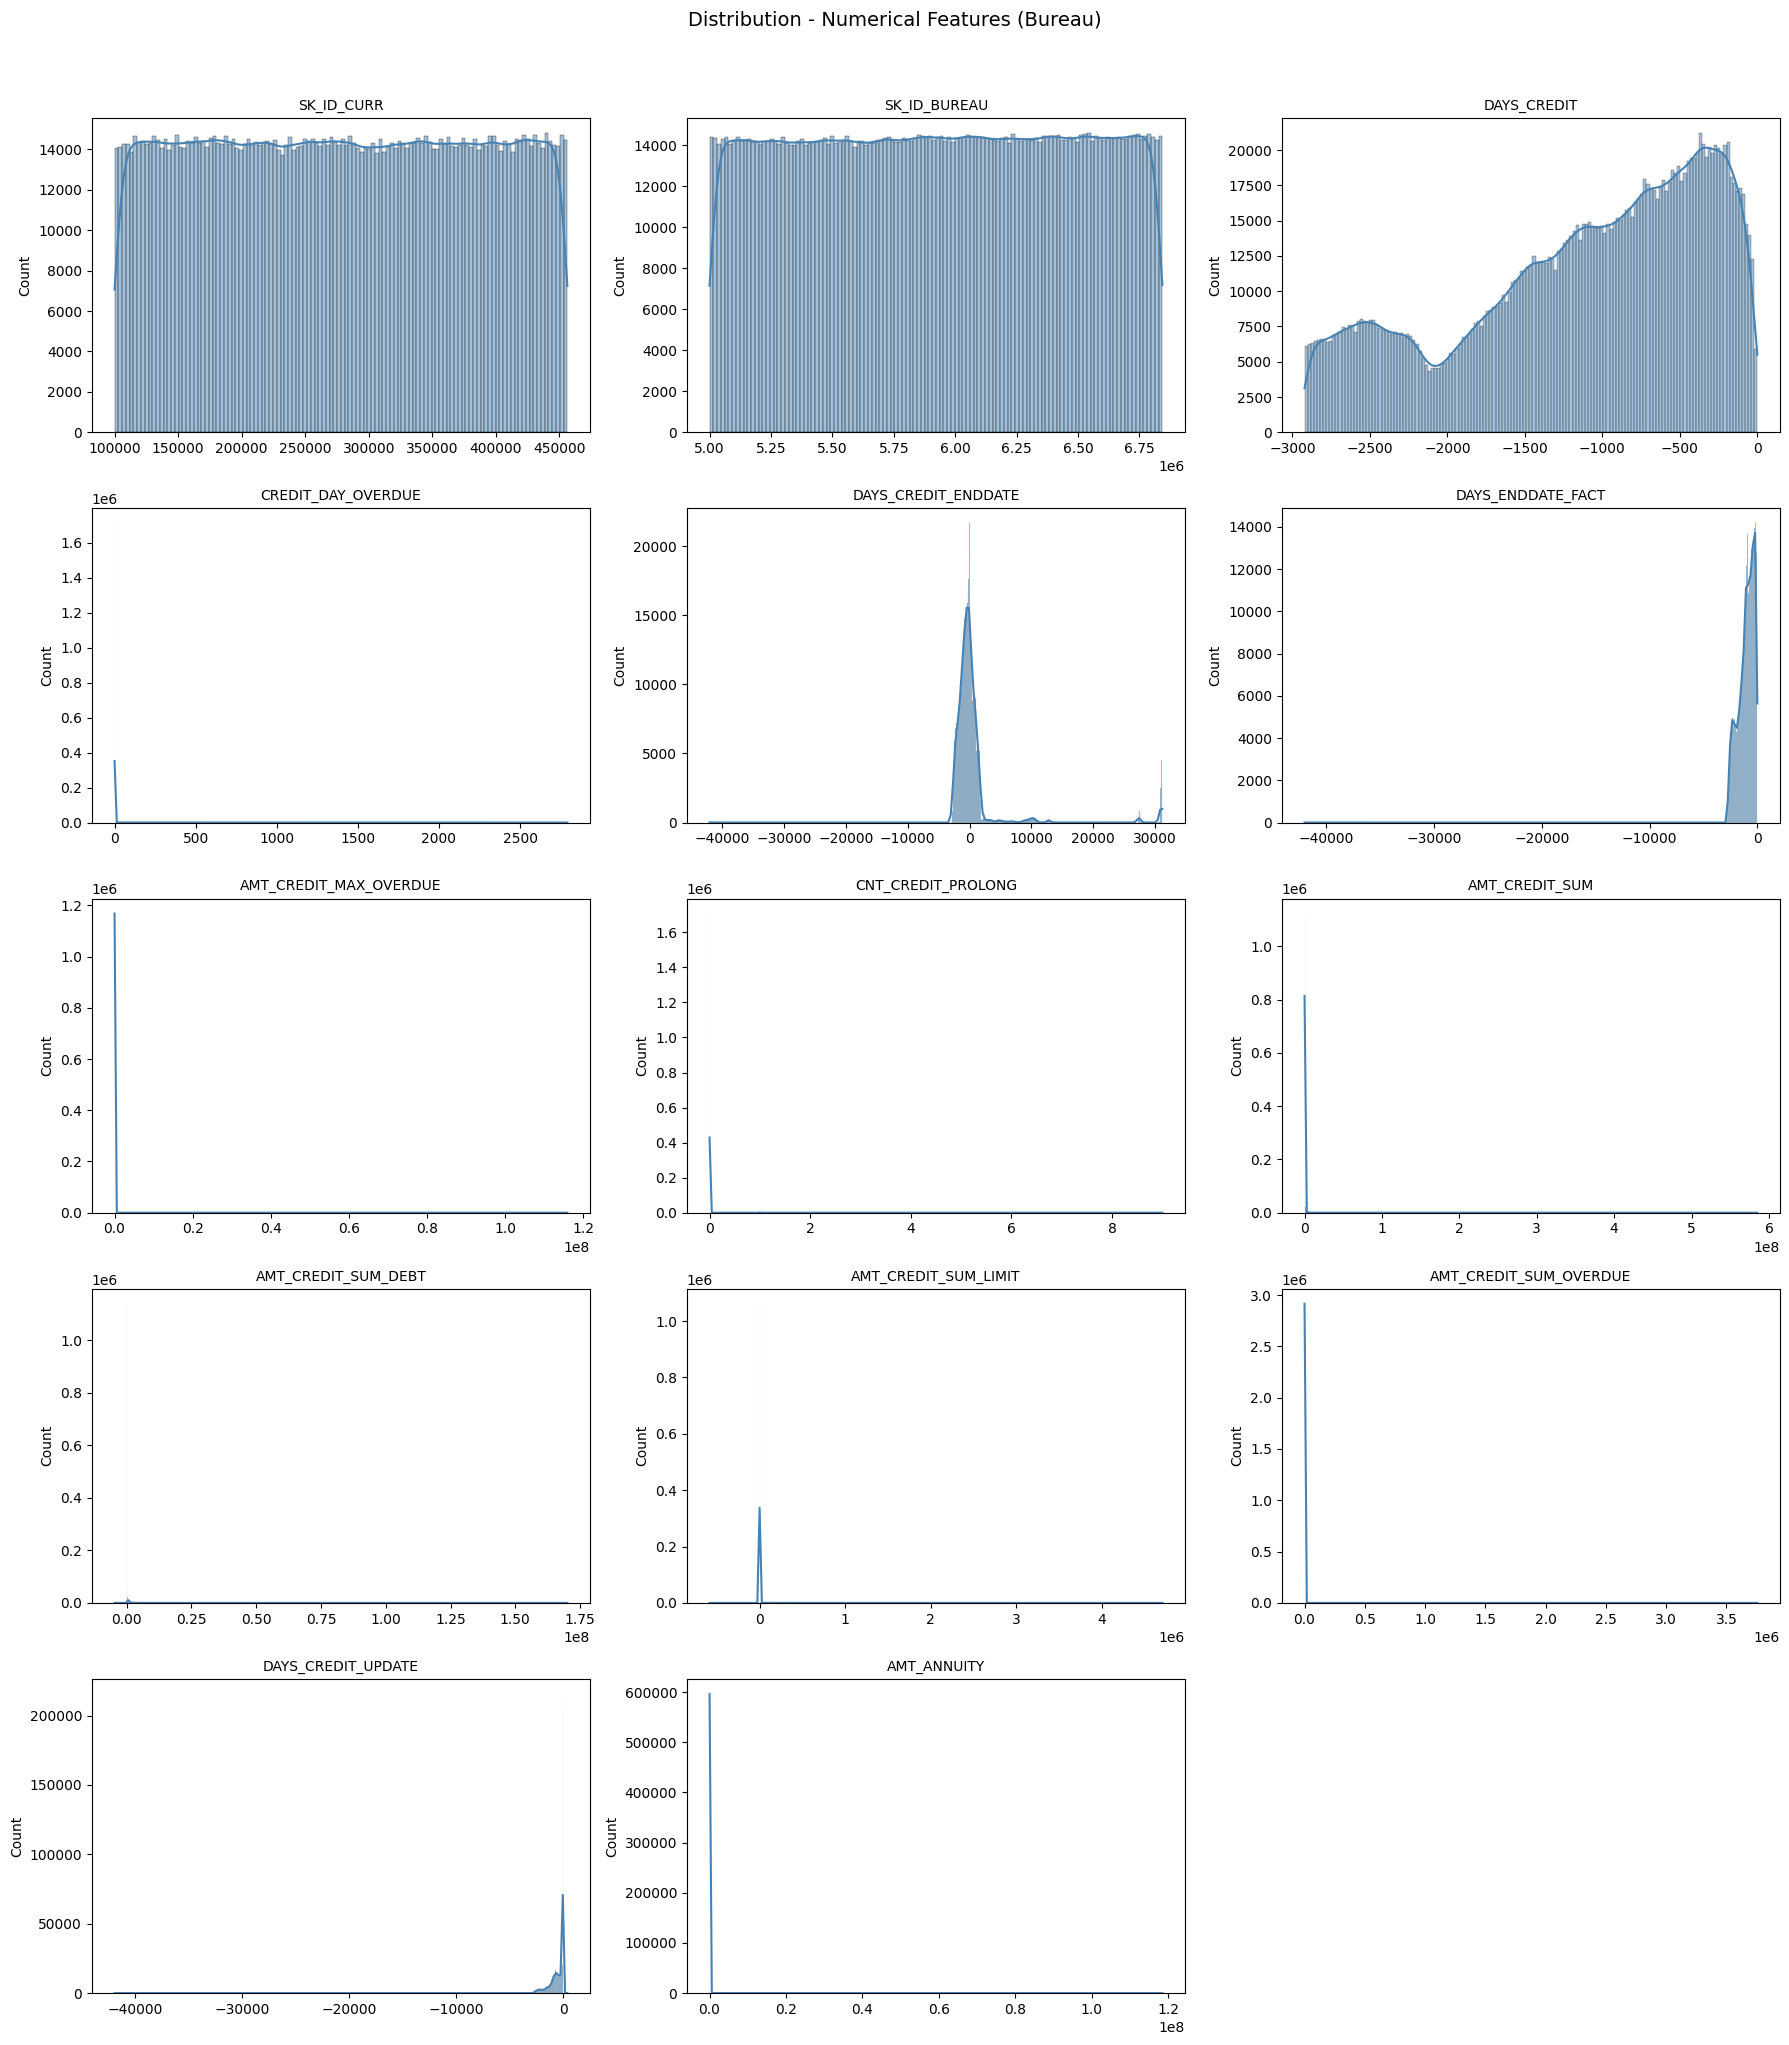

In [60]:
# Distribution plot for each numerical feature
ncols = 3
nrows = math.ceil(len(num_cols_bureau) / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols_bureau):
    sns.histplot(df_bureau[col].dropna(), ax=axes[i], kde=True, color='steelblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribution - Numerical Features (Bureau)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### 4.1.1.3 Outlier Detection

Boxplots are used to detect outliers in numerical features. Extreme values can distort model training and may require capping or domain-aware treatment before modeling.

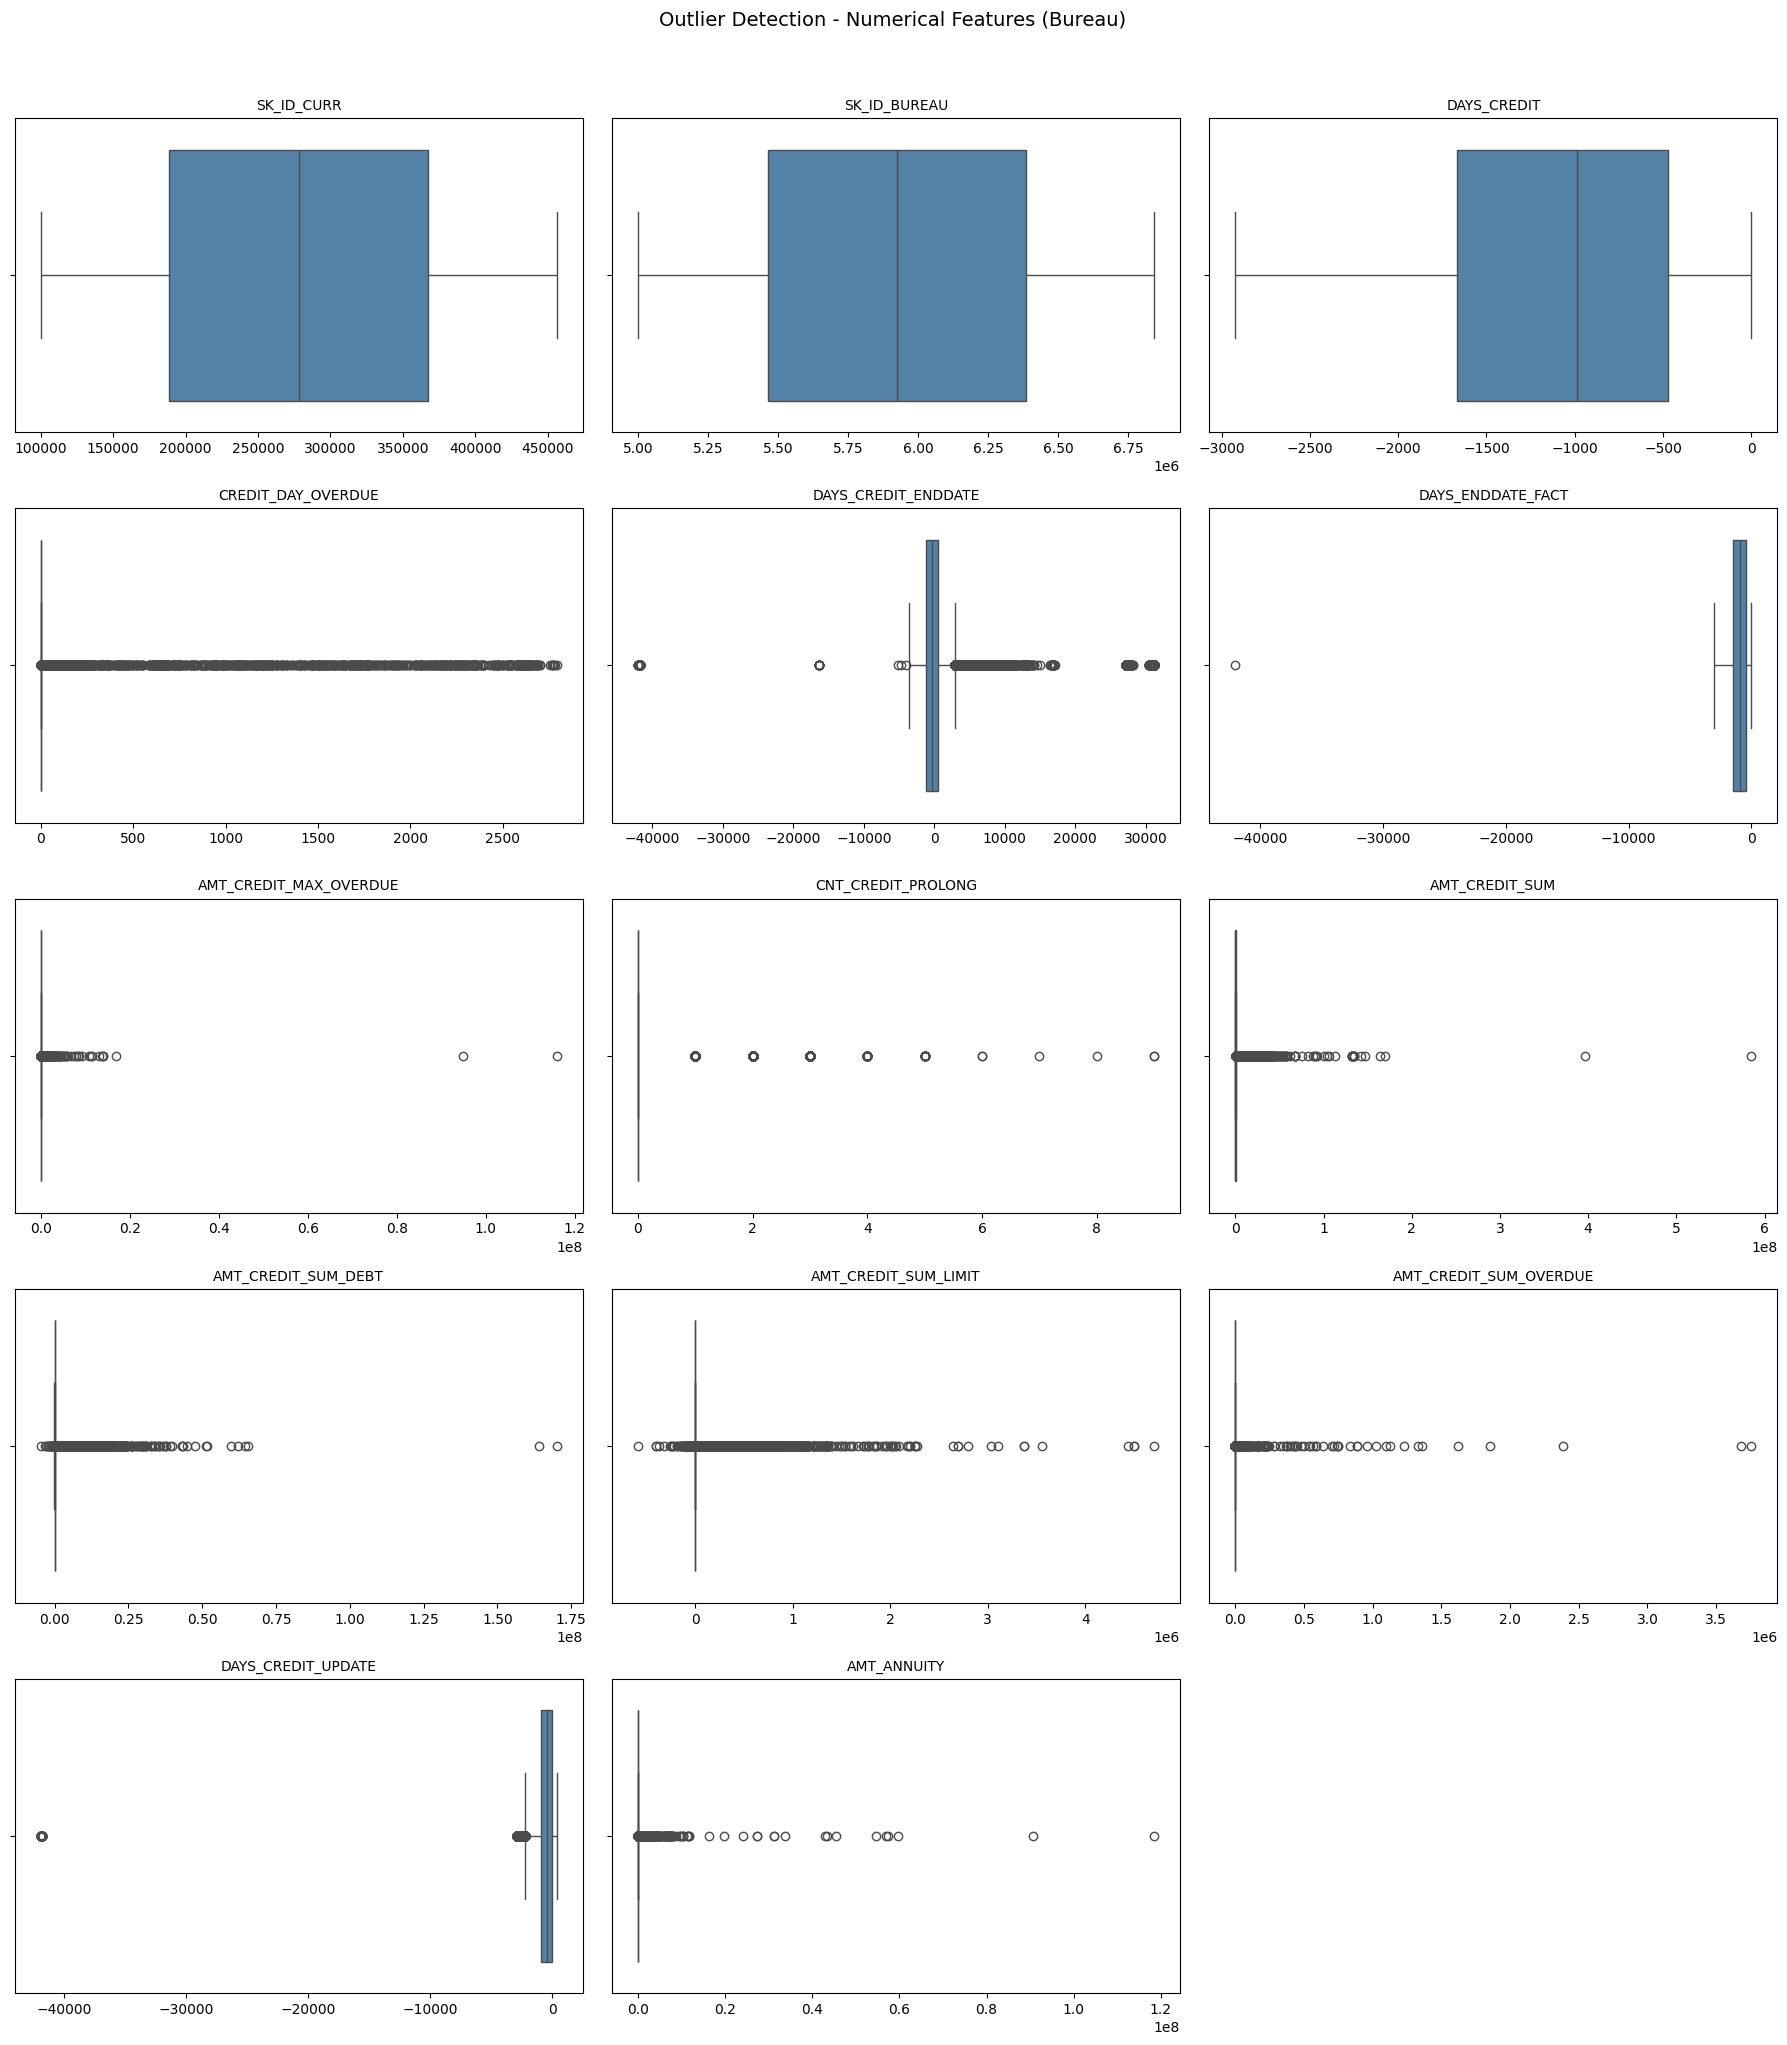

In [62]:
# Outlier detection using boxplot
ncols = 3
nrows = math.ceil(len(num_cols_bureau) / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols_bureau):
    sns.boxplot(x=df_bureau[col].dropna(), ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Outlier Detection - Numerical Features (Bureau)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4.1.2 Bivariate Between Features

This section examines pairwise correlations between numerical features in `bureau` to detect multicollinearity and identify redundant features.

The approach includes:
- **Heatmap** to visualize pairwise correlation between numerical features

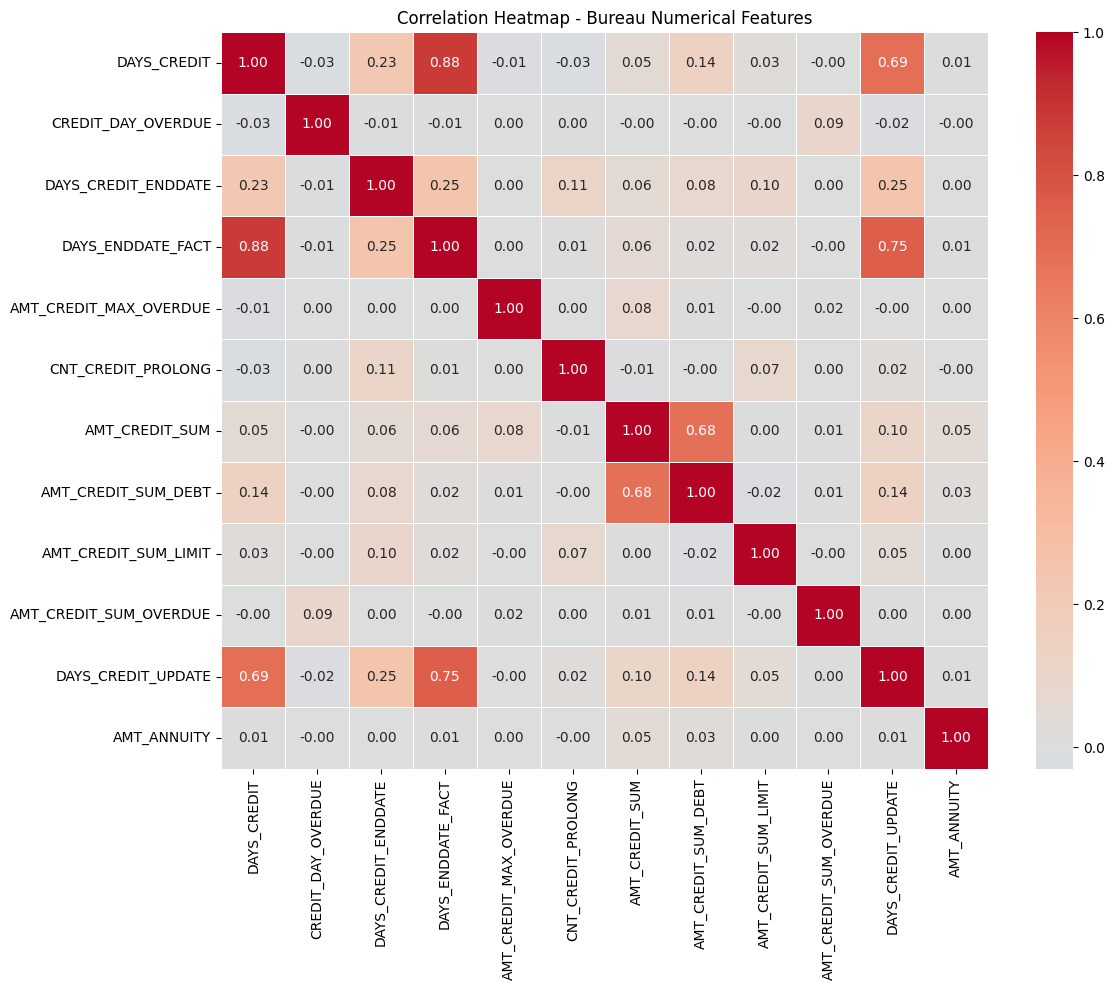

In [56]:
# Correlation heatmap - all numerical features
plt.figure(figsize=(12, 10))

corr_bureau = df_bureau[num_cols_bureau].corr()

sns.heatmap(
    corr_bureau,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Correlation Heatmap - Bureau Numerical Features')
plt.tight_layout()
plt.show()

## 4.2 Bureau Balance


In [61]:
# Select numerical columns
num_cols_bureau_balance = df_bureau_balance.select_dtypes(include='number').columns

### 4.2.1 Univariate


#### 4.2.1.1 Statistical Descriptive

In [ ]:
df_bureau_balance[num_cols_bureau].describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_BUREAU,27299925.0,6.036297e+06,492348.856904,5001709.0,5730933.0,6070821.0,6431951.0,6842888.0
MONTHS_BALANCE,27299925.0,-3.074169e+01,23.864509,-96.0,-46.0,-25.0,-11.0,0.0


#### 4.2.1.2 Distribution Plot

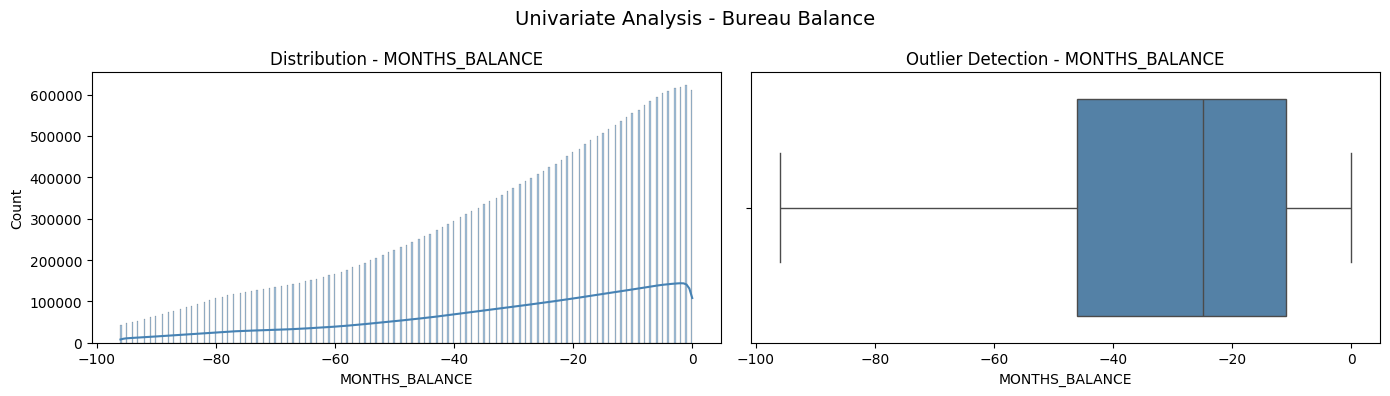

In [ ]:
# Distribution plot for each numerical feature
ncols = 3
nrows = math.ceil(len(num_cols_bureau_balance) / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols_bureau_balance):
    sns.histplot(df_bureau_balance[col].dropna(), ax=axes[i], kde=True, color='steelblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribution - Numerical Features (Bureau Balance)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4.2.2 Bivariate Analysis

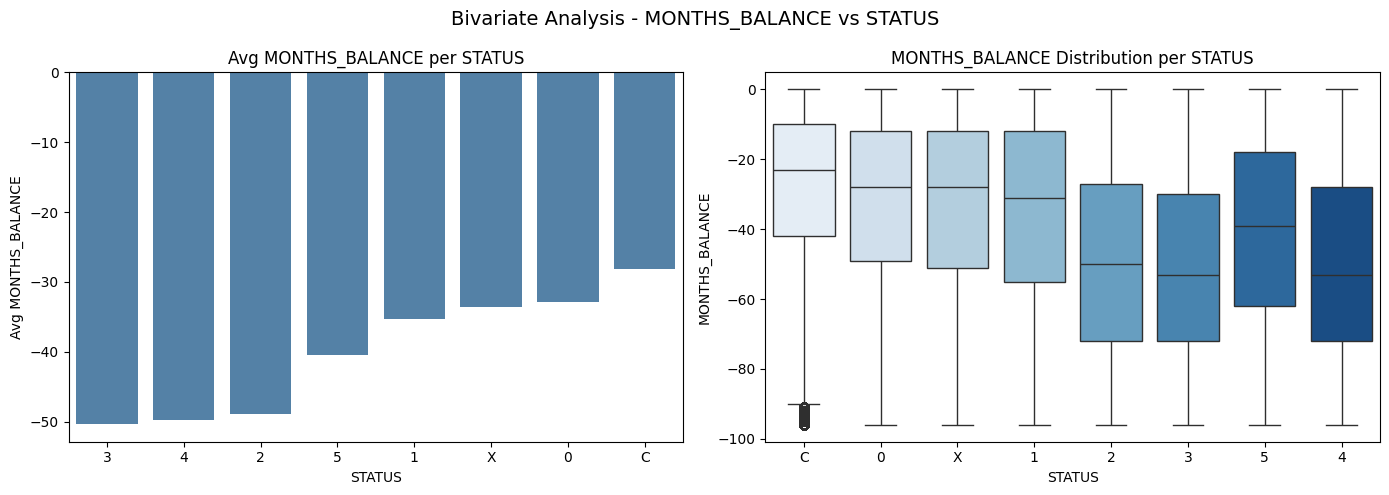

In [ ]:
# Correlation heatmap - all numerical features
plt.figure(figsize=(12, 10))

corr_bureau = df_bureau[num_cols_bureau_balance].corr()

sns.heatmap(
    corr_bureau,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Correlation Heatmap - Bureau Numerical Features')
plt.tight_layout()
plt.show()

# 5. Categorical Features Analysis





## 5.1 Bureau


### 5.1.1 Univariate


### 5.1.2 Bivariate Antar Fitur



## 5.2 Bureau Balance


### 5.2.1 Univariate


### 5.2.2 Bivariate Antar Fitur

# 6. Agregasi





## 5.1 Bureau Balance ke SK_ID_BUREAU


## 5.2 Bureau (+ Bureau Balance) ke SK_ID_CURR

# 6. Bivariate Aggregated Features vs TARGET





## 6.1 Numerical Aggregated Features


## 6.2 Categorical Aggregated Features

# 7. Insights & Recommendations



## 7.1 Key Findings


## 7.2 Aggregated Features yang Direkomendasikan


## 7.3 Handling Strategy

In [30]:
# Read markdown cells from notebook
import json

with open('EDA_bureau_and_bureau_balance.ipynb', 'r', encoding='utf-8') as f:
    nb = json.load(f)

for i, cell in enumerate(nb['cells']):
    if cell['cell_type'] == 'markdown':
        print(f"--- Cell {i} ---")
        print(''.join(cell['source']))
        print()

--- Cell 0 ---
# Exploratory Data Analysis (EDA)
## Dataset: bureau & bureau_balance

**Author:** Oknardo Tulung  
**LinkedIn:** https://www.linkedin.com/in/oknardo-tulung/  
**GitHub:** https://github.com/oknardo/Home_Credit_Scorecard_Model

---

## 📌 Project Overview
This notebook performs a comprehensive Exploratory Data Analysis (EDA) on the `bureau` and `bureau_balance` datasets from the Home Credit risk modeling case. These tables contain clients' previous credit history reported to the Credit Bureau, which serve as key external behavioral signals for predicting loan default.

---

## 🎯 Objectives
- Understand the structure and relationship between `bureau` and `bureau_balance`
- Identify data quality issues (missing values, outliers, inconsistencies)
- Analyze the distribution of key variables
- Explore relationships between aggregated features and the target variable (loan default)
- Generate aggregated features ready for merging into the main table

---

## 🔍 Analysis Scope
Th